# Bibliotekos

In [5]:
import os
import zipfile
from pathlib import Path
import shutil
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Direktorijos nustatymai

In [6]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]
print(f"Current working directory: {base_path}")
print(f"Repository root directory: {repo_root}")

Current working directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\Duomenu_mokslo_projektas\code\python\datasets_prep
Repository root directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT


# UNZIP

In [3]:
SOURCE_DIR = os.path.join(repo_root, "CAMS_Downloads", "particulate_matter_10um")
TARGET_DIR = os.path.join(repo_root, "CAMS unzip", "particulate_matter_10um")

os.makedirs(TARGET_DIR, exist_ok=True)

for file_name in os.listdir(SOURCE_DIR):
    if file_name.endswith(".zip"):
        zip_path = os.path.join(SOURCE_DIR, file_name)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            internal_files = zip_ref.namelist()
            
            nc_files = [f for f in internal_files if f.endswith('.nc')]
            
            for nc_file in nc_files:
                target_file_name = file_name.replace(".zip", ".nc")
                
                source = zip_ref.open(nc_file)
                target_path = os.path.join(TARGET_DIR, target_file_name)
                
                with open(target_path, "wb") as target:
                    shutil.copyfileobj(source, target)
                
                print(f"Extracted and flattened: {target_file_name}")

print("\nDone! All .nc files are now in:", TARGET_DIR)

Extracted and flattened: cams_2018_01_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_02_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_03_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_04_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_05_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_06_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_07_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_08_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_09_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_10_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_11_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2018_12_particulate_matter_10um_validated.nc
Extracted and flattened: cams_2019_01_particulate_matter_10um_validated.nc
Extracted and flattened: 

# Patikrinimas

In [18]:
file_path = r"C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\CAMS unzip\dust\cams_2020_10_dust_validated.nc"

ds = xr.open_dataset(file_path)
print(ds)

<xarray.Dataset> Size: 113kB
Dimensions:  (time: 744, lat: 6, lon: 6)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-10-01 ... 2020-10-31T23:00:00
  * lat      (lat) float64 48B 54.45 54.55 54.65 54.75 54.85 54.95
  * lon      (lon) float64 48B 25.05 25.15 25.25 25.35 25.45 25.55
Data variables:
    dust     (time, lat, lon) float32 107kB ...
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality validated reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service


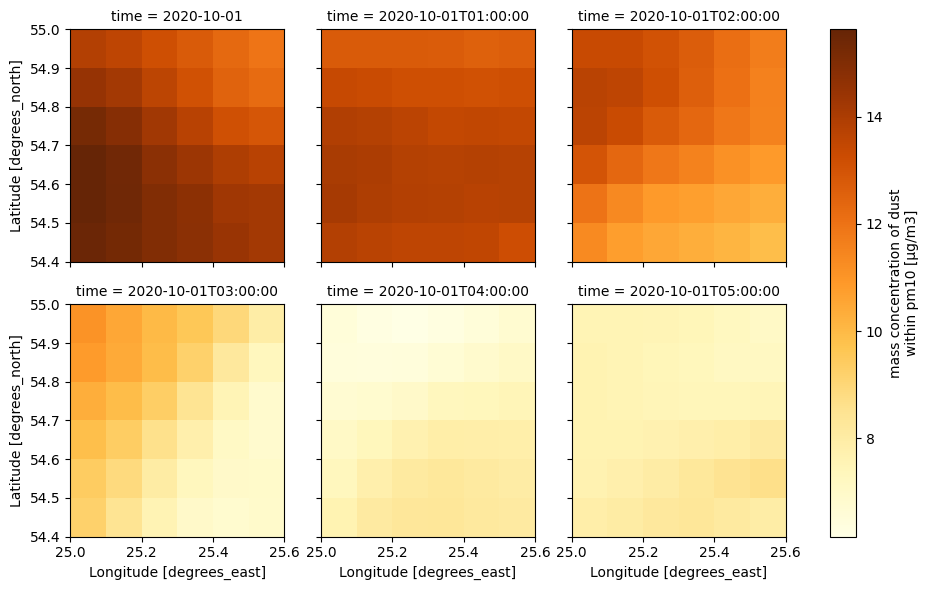

In [19]:
plot = ds.dust.isel(time=slice(0, 6)).plot(
    col="time", 
    col_wrap=3, 
    cmap="YlOrBr"
)

plt.show()

Text(0, 0.5, '')

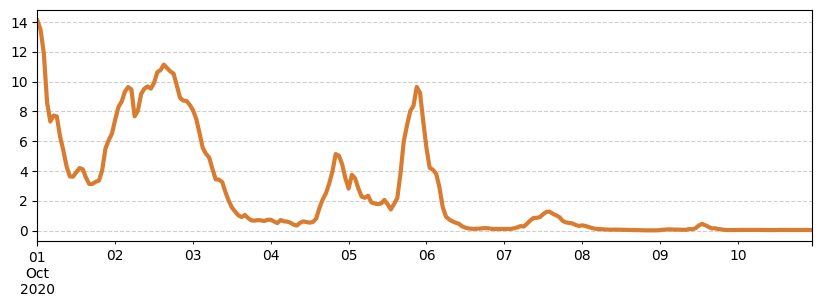

In [35]:
ds_regional = ds.mean(dim=['lat', 'lon', ]).to_dataframe()

ds_regional['dust'][:240].plot(
    figsize=(10, 3), 
    color="#d87c31", 
    linewidth=3
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("")
plt.ylabel("")

Text(0, 0.5, '')

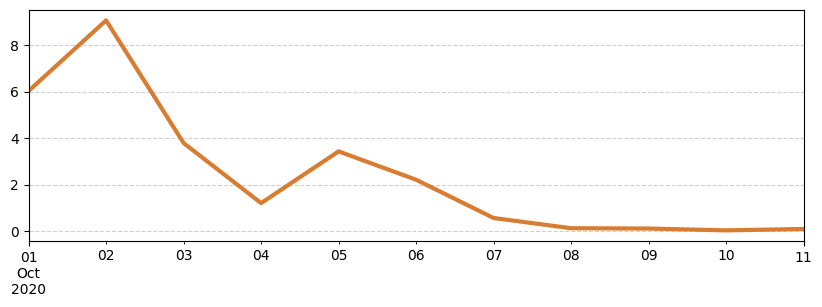

In [36]:
ds_regional.index = ds_regional.index.tz_localize('UTC')
ds_regional.index = ds_regional.index.tz_convert('Europe/Vilnius')
df_new = ds_regional.groupby(ds_regional.index.floor('D')).mean().reset_index()

df_new.set_index('time')['dust'][:11].plot(
    figsize=(10, 3), 
    color="#d87c31", 
    linewidth=3
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("")
plt.ylabel("")

In [ ]:
df_new.head(10)

,time,dust
0,2018-07-01,0.021869
1,2018-07-02,0.010687
2,2018-07-03,0.011107
3,2018-07-04,0.061477
4,2018-07-05,0.126916
5,2018-07-06,0.091501
6,2018-07-07,0.055703
7,2018-07-08,0.148385
8,2018-07-09,0.314007
9,2018-07-10,0.138796


# Apjungimas

In [21]:
with open(os.path.join(repo_root, "cams_data", "lithuania_dust_vilnius.csv"), 'r') as f:
    df_dust = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_secondary_inorganic_aerosol_vilnius.csv"), 'r') as f:
    df_secondary_inorganic_aerosol = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_particulate_matter_25um_vilnius.csv"), 'r') as f:
    df_particulate_matter_25um = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_peroxyacyl_nitrates_vilnius.csv"), 'r') as f:
    df_peroxyacyl_nitrates = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_non_methane_vocs_vilnius.csv"), 'r') as f:
    df_non_methane_vocs = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_ammonia_vilnius.csv"), 'r') as f:
    df_ammonia = pd.read_csv(f)
with open(os.path.join(repo_root, "cams_data", "lithuania_particulate_matter_10um_vilnius.csv"), 'r') as f:
    df_particulate_matter_10um = pd.read_csv(f)


In [22]:
df_dust.head(10)

,time,dust
0,2018-01-01 00:00:00+02:00,0.027574
1,2018-01-02 00:00:00+02:00,0.027978
2,2018-01-03 00:00:00+02:00,0.028735
3,2018-01-04 00:00:00+02:00,0.004460
4,2018-01-05 00:00:00+02:00,0.001764
5,2018-01-06 00:00:00+02:00,0.005255
6,2018-01-07 00:00:00+02:00,0.016525
7,2018-01-08 00:00:00+02:00,0.024140
8,2018-01-09 00:00:00+02:00,0.030266
9,2018-01-10 00:00:00+02:00,0.012182


In [ ]:
dfs = [
    df_dust, df_secondary_inorganic_aerosol, df_particulate_matter_25um,
    df_peroxyacyl_nitrates, df_non_methane_vocs, df_ammonia, df_particulate_matter_10um
]

cleaned_dfs = []

# TODO: #2 Duplicate timestamps found!
for df in dfs:
    # df['time'] = pd.to_datetime(df['time'])
    
    if df['time'].duplicated().any():
        print(f"Duplicate timestamps found! Keeping the first occurrence.")
        df = df.drop_duplicates(subset='time')
    
    df = df.set_index('time')
    cleaned_dfs.append(df)

# 2. Combine them
df_combined = pd.concat(cleaned_dfs, axis=1)
df_combined = df_combined.reset_index()

Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.
Duplicate timestamps found! Keeping the first occurrence.


In [25]:
df_combined.to_csv("CAMS_data.csv")

# Vizualizavimas

In [7]:
df = pd.read_csv('CAMS_data.csv')

In [8]:
df.describe()

,Unnamed: 0,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
count,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,1460.500000,0.598596,2.519712,6.165969,1.179312,5.278019,0.340937,8.178053
std,843.653069,2.159000,2.005411,3.824598,0.534661,2.625874,0.358328,5.084677
min,0.000000,0.000003,0.108869,0.761829,0.137872,0.931358,0.000200,0.978953
25%,730.250000,0.024336,1.123835,3.465484,0.797061,3.280724,0.055157,4.851451
50%,1460.500000,0.094065,1.979738,5.240009,1.074914,4.831596,0.243888,7.085242
75%,2190.750000,0.364384,3.278420,7.786732,1.456335,6.746521,0.503386,10.177075
max,2921.000000,50.646255,16.547606,34.634136,4.086889,21.424860,3.800120,74.083680


In [17]:
df[df['dust'] > 50]

,Unnamed: 0,time,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
2282,2282,2024-04-01,50.646255,3.04755,24.144798,0.856622,5.20003,0.855,74.08368


<Axes: xlabel='time'>

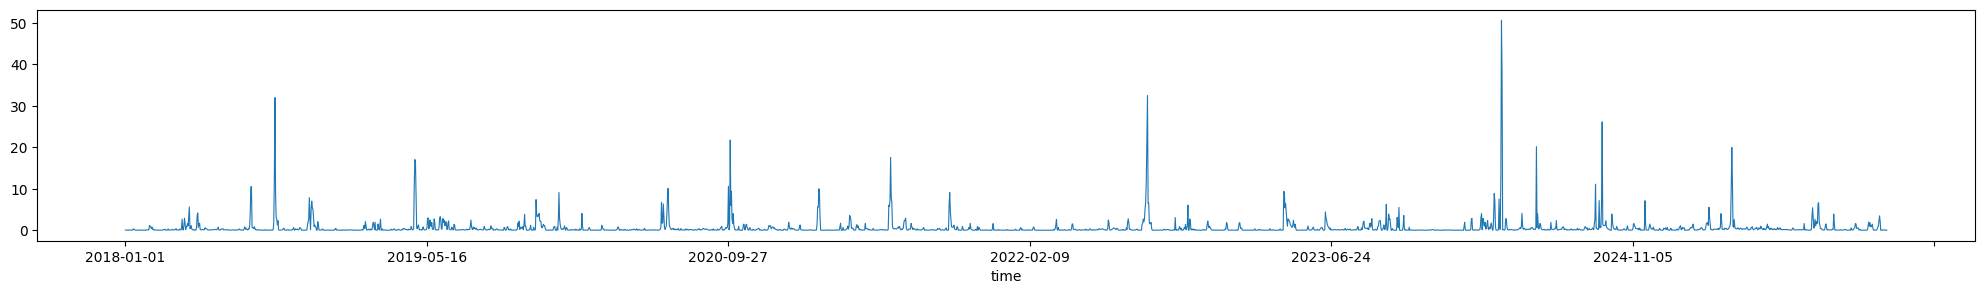

In [16]:
df.set_index('time').dust.plot(figsize=(25, 3), linewidth = 0.8)
# df.pm2p5.plot(figsize=(25, 3), linewidth = 0.5)